# 05 - Time Series Feature Engineering

**Purpose:** create the pre-COVID modeling table for one-month-ahead community-attention forecasting.

Each row is a business at feature month `t`. The table supports two targets:

- regression: review count in month `t + 1`;
- classification: whether month `t + 1` is an attention pulse.

The cohort keeps businesses with at least **100 reviews** and **36 active months inside the 2015-2019 pre-COVID modeling window**. Target months stop at **2019-12**.

The features combine time-series history, business metadata, social exposure, and lightweight NLP signals from recent review text.


## Configuration

Let's define the modeling window, active-business cohort thresholds, attention-pulse rule, and NLP lexicons.


In [16]:
# Imports
from pathlib import Path
import json
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Project paths
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

INTERIM_DIR = PROJECT_ROOT / "data" / "interim" / "new_orleans"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "new_orleans"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures" / "feature_engineering"
EDA_FIGURES_DIR = OUTPUTS_DIR / "figures" / "eda"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EDA_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Input files
BUSINESSES_PATH = INTERIM_DIR / "businesses.jsonl"
REVIEWS_PATH = INTERIM_DIR / "reviews.jsonl"
USER_NETWORK_FEATURES_PATH = PROCESSED_DIR / "user_network_features.csv"

# Output files
FORECASTING_DATASET_PATH = PROCESSED_DIR / "forecasting_dataset.csv"
MODELING_TABLE_WITH_SENTIMENT_PATH = PROCESSED_DIR / "modeling_table_with_sentiment.parquet"
COHORT_BUSINESSES_PATH = PROCESSED_DIR / "forecasting_cohort_businesses.csv"
FEATURE_SUMMARY_PATH = PROCESSED_DIR / "forecasting_feature_summary.json"
TFIDF_TERMS_OUTPUT_PATH = OUTPUTS_DIR / "nlp_tfidf_terms.csv"

# Modeling windows
MIN_TOTAL_REVIEWS = 100
MIN_ACTIVE_MONTHS = 36
MODELING_START = pd.Period("2015-01", freq="M")
MODELING_END_FEATURE = pd.Period("2019-11", freq="M")
MODELING_END_TARGET = pd.Period("2019-12", freq="M")
EXCLUDED_POST_MODELING_START = "2020-01"

# Target and NLP settings
PULSE_MIN_TARGET_REVIEWS = 3
PULSE_ABSOLUTE_LIFT = 2
PULSE_RELATIVE_LIFT = 1.5
RECENT_TEXT_WINDOW_MONTHS = 3
TFIDF_MAX_FEATURES = 50
TFIDF_MIN_DF = 20
VADER_POSITIVE_THRESHOLD = 0.05
VADER_NEGATIVE_THRESHOLD = -0.05

# Display and plot settings
pd.set_option("display.max_columns", 120)
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"Project root: {PROJECT_ROOT.name}")

Project root: community-forecasting-yelp


In [17]:
# Read JSONL records
def iter_jsonl(path):
    with path.open("r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            try:
                yield json.loads(line)
            except json.JSONDecodeError as exc:
                raise ValueError(f"Invalid JSON in {path} at line {line_number}") from exc


# Category flag
def has_category(categories, keywords):
    text = str(categories).lower()
    return int(any(keyword in text for keyword in keywords))


# Sentiment words
POSITIVE_WORDS = {
    "amazing", "awesome", "best", "delicious", "excellent", "favorite", "friendly", "fresh",
    "great", "happy", "love", "loved", "perfect", "recommend", "recommended", "tasty",
    "wonderful",
}

NEGATIVE_WORDS = {
    "awful", "bad", "bland", "cold", "disappointed", "disappointing", "dirty", "horrible",
    "overpriced", "poor", "rude", "slow", "terrible", "unfriendly", "worst",
}

POSITIVE_PATTERN = re.compile(r"\b(" + "|".join(sorted(POSITIVE_WORDS)) + r")\b", flags=re.IGNORECASE)
NEGATIVE_PATTERN = re.compile(r"\b(" + "|".join(sorted(NEGATIVE_WORDS)) + r")\b", flags=re.IGNORECASE)


# Count word matches
def count_matches(text, pattern):
    return len(pattern.findall(str(text)))


# Clean TF-IDF names
def safe_tfidf_column_name(term):
    cleaned = re.sub(r"[^0-9a-zA-Z]+", "_", term.lower()).strip("_")
    return f"tfidf_recent_{cleaned[:45]}"

In [18]:
# Load businesses
businesses = pd.DataFrame([
    {
        "business_id": r["business_id"],
        "name": r.get("name"),
        "business_stars": r.get("stars"),
        "business_review_count": r.get("review_count"),
        "categories": r.get("categories") or "",
    }
    for r in iter_jsonl(BUSINESSES_PATH)
])

# Load reviews
review_rows = []

for r in iter_jsonl(REVIEWS_PATH):
    review_rows.append({
        "review_id": r["review_id"],
        "business_id": r["business_id"],
        "user_id": r["user_id"],
        "stars": float(r["stars"]),
        "date": r["date"],
        "text": r.get("text") or "",
    })

reviews = pd.DataFrame(review_rows)

# Prepare review dates
reviews["date"] = pd.to_datetime(reviews["date"])
reviews["month"] = reviews["date"].dt.to_period("M")
reviews = reviews[reviews["month"] <= MODELING_END_TARGET].copy()

print("businesses", businesses.shape)
print("reviews", reviews.shape, reviews["month"].min(), reviews["month"].max())

businesses (6215, 5)
reviews (556092, 7) 2005-03 2019-12


## Active Modeling Cohort

Here we select businesses using only the 2015-2019 pre-COVID modeling window. This avoids keeping businesses that qualified historically but were inactive during the period being modeled.


In [19]:
# Monthly review counts
monthly_counts = (
    reviews.groupby(["business_id", "month"])
    .size()
    .rename("monthly_review_count")
    .reset_index()
)

# Modeling window counts
modeling_window_counts = monthly_counts[
    (monthly_counts["month"] >= MODELING_START)
    & (monthly_counts["month"] <= MODELING_END_TARGET)
].copy()

# Business activity
business_activity = (
    modeling_window_counts
    .groupby("business_id")
    .agg(
        total_reviews=("monthly_review_count", "sum"),
        active_months=("month", "nunique"),
    )
    .reset_index()
)

# Select cohort
cohort = business_activity[
    (business_activity["total_reviews"] >= MIN_TOTAL_REVIEWS)
    & (business_activity["active_months"] >= MIN_ACTIVE_MONTHS)
].copy()

cohort = cohort.merge(businesses, on="business_id", how="left")
cohort.to_csv(COHORT_BUSINESSES_PATH, index=False)
cohort_ids = cohort["business_id"].tolist()

print(f"Forecasting cohort businesses: {len(cohort_ids):,}")
cohort[["business_id", "name", "total_reviews", "active_months"]].head()

Forecasting cohort businesses: 715


,business_id,name,total_reviews,active_months
0,-1XSzguS6XLN-V6MVZMg2A,Restaurant Rebirth,461,49
1,-A2OLubXDsMRPNN7LqohPA,Rollin Fatties,147,52
2,-AaxZJ_I4rSFOBJbBz4SlQ,Hansen's Sno-Bliz,310,52
3,-Tskf8WK17rb3ZfeFuRSWA,Palace Café,1118,60
4,-UEeCTgxud4OGWshX4x-jw,Drip Affogato Bar,342,40


## Time-Series Features

Let's create one row per business-month, then add lagged and rolling review-history features. Target columns always refer to the next month.


In [20]:
# Business-month panel
all_months = pd.period_range(MODELING_START, MODELING_END_TARGET, freq="M")
index = pd.MultiIndex.from_product([cohort_ids, all_months], names=["business_id", "feature_month"])
panel = pd.DataFrame(index=index).reset_index()

# Monthly stars and reviews
monthly_star_stats = (
    reviews[reviews["business_id"].isin(cohort_ids)]
    .groupby(["business_id", "month"])
    .agg(
        monthly_review_count=("review_id", "size"),
        monthly_star_sum=("stars", "sum"),
    )
    .reset_index()
    .rename(columns={"month": "feature_month"})
)

# Merge monthly data
panel = panel.merge(monthly_star_stats, on=["business_id", "feature_month"], how="left")
panel["monthly_review_count"] = panel["monthly_review_count"].fillna(0).astype(int)
panel["monthly_star_sum"] = panel["monthly_star_sum"].fillna(0.0)
panel = panel.sort_values(["business_id", "feature_month"])

# Time-series features
by_business = panel.groupby("business_id", group_keys=False)

panel["prev_month_reviews"] = panel["monthly_review_count"]
panel["rolling_3_avg"] = by_business["monthly_review_count"].rolling(3, min_periods=1).mean().reset_index(level=0, drop=True)
panel["rolling_6_avg"] = by_business["monthly_review_count"].rolling(6, min_periods=1).mean().reset_index(level=0, drop=True)
panel["same_month_previous_year"] = by_business["monthly_review_count"].shift(12).fillna(0)
panel["cumulative_review_count"] = by_business["monthly_review_count"].cumsum()
panel["cumulative_star_sum"] = by_business["monthly_star_sum"].cumsum()
panel["avg_rating_history"] = np.where(
    panel["cumulative_review_count"] > 0,
    panel["cumulative_star_sum"] / panel["cumulative_review_count"],
    0.0,
)

# Target
panel["target_next_month_reviews"] = by_business["monthly_review_count"].shift(-1)
panel["target_month"] = panel["feature_month"] + 1

panel.head()

,business_id,feature_month,monthly_review_count,monthly_star_sum,prev_month_reviews,rolling_3_avg,rolling_6_avg,same_month_previous_year,cumulative_review_count,cumulative_star_sum,avg_rating_history,target_next_month_reviews,target_month
0,-1XSzguS6XLN-V6MVZMg2A,2015-01,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2015-02
1,-1XSzguS6XLN-V6MVZMg2A,2015-02,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2015-03
2,-1XSzguS6XLN-V6MVZMg2A,2015-03,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2015-04
3,-1XSzguS6XLN-V6MVZMg2A,2015-04,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2015-05
4,-1XSzguS6XLN-V6MVZMg2A,2015-05,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2015-06


In [21]:
# Business flags
business_features = businesses.assign(
    is_restaurant=lambda df: df["categories"].apply(lambda x: has_category(x, ["restaurant"])),
    is_food=lambda df: df["categories"].apply(lambda x: has_category(x, ["food", "coffee", "tea", "bakery", "dessert"])),
    is_nightlife=lambda df: df["categories"].apply(lambda x: has_category(x, ["nightlife", "bar", "pub", "cocktail"])),
    is_tourism=lambda df: df["categories"].apply(lambda x: has_category(x, ["hotels & travel", "hotel", "event planning", "arts & entertainment", "local flavor", "tour"])),
)[[
    "business_id",
    "business_stars",
    "business_review_count",
    "is_restaurant",
    "is_food",
    "is_nightlife",
    "is_tourism",
]]

# Add business features
panel = panel.merge(business_features, on="business_id", how="left")

In [22]:
# Load network features
user_network_features = pd.read_csv(USER_NETWORK_FEATURES_PATH)
user_network_features["community_id"] = user_network_features["community_id"].fillna(-1).astype(int)

# User first month
user_first_month = reviews.groupby("user_id")["month"].min().rename("user_first_month").reset_index()

# Social signal thresholds
DYNAMIC_ACTIVE_REVIEW_THRESHOLD = 5
HIGH_SOCIAL_SIGNAL_QUANTILE = 0.90

active_network_users = user_network_features[user_network_features["active_reviewer"].eq(1)].copy()
high_weighted_pagerank_cutoff = active_network_users["weighted_pagerank"].quantile(HIGH_SOCIAL_SIGNAL_QUANTILE)
high_weighted_degree_cutoff = active_network_users["friend_weighted_degree"].quantile(HIGH_SOCIAL_SIGNAL_QUANTILE)

# User activity over time
reviews["month_number_global"] = reviews["month"].dt.year * 12 + reviews["month"].dt.month

user_month_activity = (
    reviews.groupby(["user_id", "month", "month_number_global"])
    .agg(user_month_review_count=("review_id", "size"))
    .reset_index()
    .sort_values(["user_id", "month_number_global"])
)

user_month_activity["reviewer_reviews_to_date"] = user_month_activity.groupby("user_id")["user_month_review_count"].cumsum()
user_month_activity["reviewer_active_months_to_date"] = user_month_activity.groupby("user_id").cumcount() + 1

# Business reviewers
reviewers = (
    reviews[reviews["business_id"].isin(cohort_ids)][["business_id", "user_id", "month", "month_number_global"]]
    .drop_duplicates()
    .merge(user_network_features, on="user_id", how="left")
    .merge(user_first_month, on="user_id", how="left")
    .rename(columns={"month_number_global": "review_month_number_global"})
)

# Network defaults
network_defaults = {
    "subset_review_count": 0,
    "active_reviewer": 0,
    "friend_degree": 0,
    "friend_weighted_degree": 0.0,
    "pagerank": 0.0,
    "weighted_pagerank": 0.0,
    "avg_friend_shared_businesses": 0.0,
    "avg_friend_category_overlap": 0.0,
    "component_id": -1,
    "component_size": 0,
    "community_id": -1,
}

for column, value in network_defaults.items():
    if column not in reviewers.columns:
        reviewers[column] = value
    reviewers[column] = reviewers[column].fillna(value)

# Expand recent reviewer window
recent_frames = []

for offset in [0, 1, 2]:
    temp = reviewers.copy()
    temp["feature_month"] = temp["month"] + offset
    recent_frames.append(temp)

recent_reviewers = pd.concat(recent_frames, ignore_index=True)
recent_reviewers = recent_reviewers[
    (recent_reviewers["feature_month"] >= all_months.min())
    & (recent_reviewers["feature_month"] <= all_months.max())
].copy()

recent_reviewers["feature_month_number_global"] = (
    recent_reviewers["feature_month"].dt.year * 12
    + recent_reviewers["feature_month"].dt.month
)

# Add reviewer history
recent_reviewers = pd.merge_asof(
    recent_reviewers.sort_values(["feature_month_number_global", "user_id"]),
    user_month_activity[[
        "user_id",
        "month_number_global",
        "reviewer_reviews_to_date",
        "reviewer_active_months_to_date",
    ]].sort_values(["month_number_global", "user_id"]),
    left_on="feature_month_number_global",
    right_on="month_number_global",
    by="user_id",
    direction="backward",
).drop(columns=["month_number_global"])

# Reviewer flags
recent_reviewers["reviewer_reviews_to_date"] = recent_reviewers["reviewer_reviews_to_date"].fillna(0)
recent_reviewers["reviewer_active_months_to_date"] = recent_reviewers["reviewer_active_months_to_date"].fillna(0)
recent_reviewers["reviewer_recency_months"] = recent_reviewers["feature_month_number_global"] - recent_reviewers["review_month_number_global"]
recent_reviewers["is_current_month_reviewer"] = recent_reviewers["reviewer_recency_months"].eq(0).astype(int)
recent_reviewers["is_repeat_reviewer"] = (recent_reviewers["user_first_month"] < recent_reviewers["feature_month"]).astype(int)
recent_reviewers["is_active_to_date_reviewer"] = (recent_reviewers["reviewer_reviews_to_date"] >= DYNAMIC_ACTIVE_REVIEW_THRESHOLD).astype(int)
recent_reviewers["is_connected_reviewer"] = (recent_reviewers["friend_degree"] > 0).astype(int)
recent_reviewers["is_weighted_connected_reviewer"] = (recent_reviewers["friend_weighted_degree"] > 0).astype(int)
recent_reviewers["is_largest_component_reviewer"] = recent_reviewers["component_id"].eq(0).astype(int)
recent_reviewers["is_high_weighted_pagerank_reviewer"] = (recent_reviewers["weighted_pagerank"] >= high_weighted_pagerank_cutoff).astype(int)
recent_reviewers["is_high_weighted_degree_reviewer"] = (recent_reviewers["friend_weighted_degree"] >= high_weighted_degree_cutoff).astype(int)

# Aggregate network exposure
network_agg = recent_reviewers.groupby(["business_id", "feature_month"]).agg(
    recent_reviewer_count=("user_id", "nunique"),
    avg_reviewer_degree=("friend_degree", "mean"),
    avg_reviewer_weighted_degree=("friend_weighted_degree", "mean"),
    max_reviewer_pagerank=("pagerank", "max"),
    max_reviewer_weighted_pagerank=("weighted_pagerank", "max"),
    avg_reviewer_weighted_pagerank=("weighted_pagerank", "mean"),
    sum_reviewer_weighted_pagerank=("weighted_pagerank", "sum"),
    sum_reviewer_weighted_degree=("friend_weighted_degree", "sum"),
    avg_reviewer_friend_shared_businesses=("avg_friend_shared_businesses", "mean"),
    avg_reviewer_friend_category_overlap=("avg_friend_category_overlap", "mean"),
    fraction_connected_reviewers=("is_connected_reviewer", "mean"),
    fraction_weighted_connected_reviewers=("is_weighted_connected_reviewer", "mean"),
    fraction_repeat_reviewers=("is_repeat_reviewer", "mean"),
    fraction_active_to_date_reviewers=("is_active_to_date_reviewer", "mean"),
    avg_reviewer_reviews_to_date=("reviewer_reviews_to_date", "mean"),
    max_reviewer_reviews_to_date=("reviewer_reviews_to_date", "max"),
    avg_reviewer_active_months_to_date=("reviewer_active_months_to_date", "mean"),
    fraction_largest_component_reviewers=("is_largest_component_reviewer", "mean"),
    fraction_high_weighted_pagerank_reviewers=("is_high_weighted_pagerank_reviewer", "mean"),
    fraction_high_weighted_degree_reviewers=("is_high_weighted_degree_reviewer", "mean"),
    avg_reviewer_recency_months=("reviewer_recency_months", "mean"),
    fraction_current_month_reviewers=("is_current_month_reviewer", "mean"),
    reviewer_community_diversity=("community_id", lambda values: values[values >= 0].nunique()),
).reset_index()

# Add network features
panel = panel.merge(network_agg, on=["business_id", "feature_month"], how="left")

# Feature groups
static_social_features = [
    "recent_reviewer_count",
    "avg_reviewer_degree",
    "avg_reviewer_weighted_degree",
    "max_reviewer_pagerank",
    "max_reviewer_weighted_pagerank",
    "avg_reviewer_weighted_pagerank",
    "sum_reviewer_weighted_pagerank",
    "sum_reviewer_weighted_degree",
    "avg_reviewer_friend_shared_businesses",
    "avg_reviewer_friend_category_overlap",
    "fraction_connected_reviewers",
    "fraction_weighted_connected_reviewers",
    "fraction_repeat_reviewers",
    "reviewer_community_diversity",
]

dynamic_social_exposure_features = [
    "fraction_active_to_date_reviewers",
    "avg_reviewer_reviews_to_date",
    "max_reviewer_reviews_to_date",
    "avg_reviewer_active_months_to_date",
    "fraction_largest_component_reviewers",
    "fraction_high_weighted_pagerank_reviewers",
    "fraction_high_weighted_degree_reviewers",
    "avg_reviewer_recency_months",
    "fraction_current_month_reviewers",
]

network_feature_columns = static_social_features + dynamic_social_exposure_features

# Fill missing network values
for col in network_feature_columns:
    panel[col] = panel[col].fillna(0)

panel.head()

,business_id,feature_month,monthly_review_count,monthly_star_sum,prev_month_reviews,rolling_3_avg,rolling_6_avg,same_month_previous_year,cumulative_review_count,cumulative_star_sum,avg_rating_history,target_next_month_reviews,target_month,business_stars,business_review_count,is_restaurant,is_food,is_nightlife,is_tourism,recent_reviewer_count,avg_reviewer_degree,avg_reviewer_weighted_degree,max_reviewer_pagerank,max_reviewer_weighted_pagerank,avg_reviewer_weighted_pagerank,sum_reviewer_weighted_pagerank,sum_reviewer_weighted_degree,avg_reviewer_friend_shared_businesses,avg_reviewer_friend_category_overlap,fraction_connected_reviewers,fraction_weighted_connected_reviewers,fraction_repeat_reviewers,fraction_active_to_date_reviewers,avg_reviewer_reviews_to_date,max_reviewer_reviews_to_date,avg_reviewer_active_months_to_date,fraction_largest_component_reviewers,fraction_high_weighted_pagerank_reviewers,fraction_high_weighted_degree_reviewers,avg_reviewer_recency_months,fraction_current_month_reviewers,reviewer_community_diversity
0,-1XSzguS6XLN-V6MVZMg2A,2015-01,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2015-02,4.5,521,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1XSzguS6XLN-V6MVZMg2A,2015-02,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2015-03,4.5,521,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1XSzguS6XLN-V6MVZMg2A,2015-03,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2015-04,4.5,521,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1XSzguS6XLN-V6MVZMg2A,2015-04,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2015-05,4.5,521,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1XSzguS6XLN-V6MVZMg2A,2015-05,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2015-06,4.5,521,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Community-Level Review Time Series

This section moves from business-month activity to reviewer-community activity. It directly ties the social-network communities back to the forecasting theme by asking whether large reviewer groups have their own aggregate review rhythms before we model individual businesses.

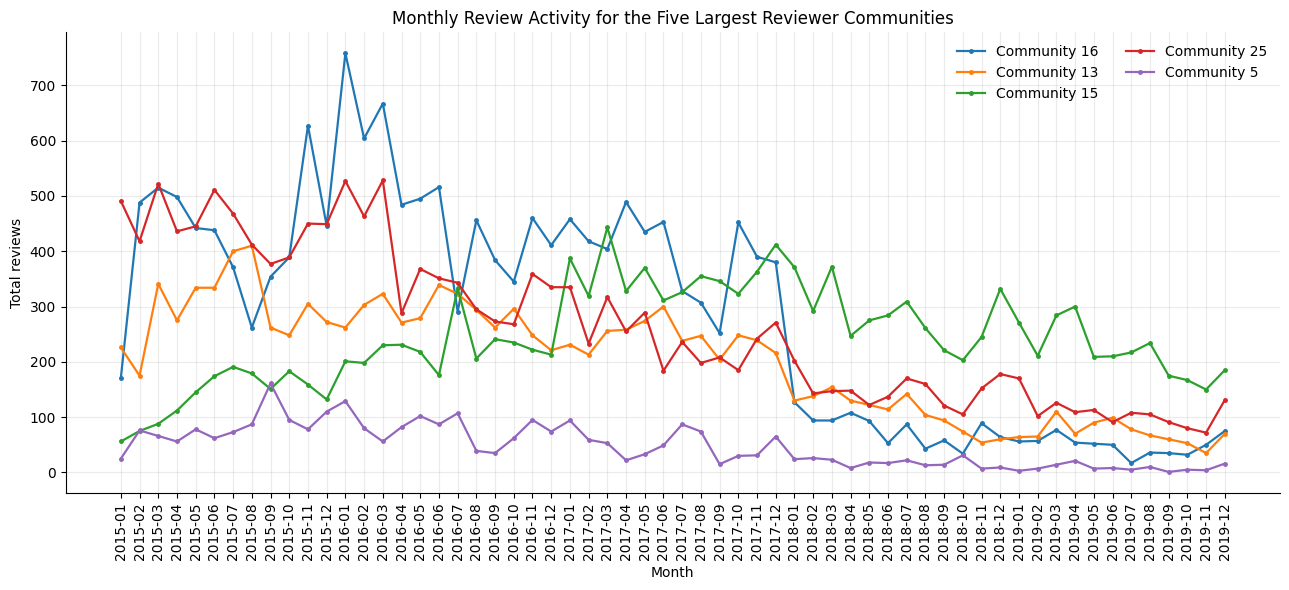

data\processed\new_orleans\community_month_series.csv
outputs\figures\feature_engineering\community_review_trends.png


,community_id,year_month,total_reviews,unique_businesses_reviewed,mean_stars,community_size,is_top5_community
0,16,2015-01,171,147,4.023392,1678,True
1,16,2015-02,488,305,4.102459,1678,True
2,16,2015-03,515,298,4.017476,1678,True
3,16,2015-04,498,293,3.879518,1678,True
4,16,2015-05,442,276,3.914027,1678,True


In [23]:
# Notebook setup
IN_NOTEBOOK = "get_ipython" in globals()
if not IN_NOTEBOOK:
    plt.switch_backend("Agg")

# Output paths
COMMUNITY_MONTH_SERIES_PATH = PROCESSED_DIR / "community_month_series.csv"
COMMUNITY_TRENDS_PATH = FIGURES_DIR / "community_review_trends.png"

# Prepare reviews
if "reviews_df" not in globals():
    reviews_df = reviews.copy()

reviews_df = reviews_df.copy()
reviews_df["date"] = pd.to_datetime(reviews_df["date"])
reviews_df["year_month"] = reviews_df["date"].dt.to_period("M")
reviews_df = reviews_df[
    (reviews_df["year_month"] >= pd.Period("2015-01", freq="M"))
    & (reviews_df["year_month"] <= MODELING_END_TARGET)
].copy()

# Community labels
if "community_labels" in globals():
    community_label_frame = (
        pd.Series(community_labels, name="community_id")
        .rename_axis("user_id")
        .reset_index()
    )
else:
    if "user_network_features" not in globals():
        user_network_features = pd.read_csv(USER_NETWORK_FEATURES_PATH)

    community_label_frame = user_network_features[["user_id", "community_id"]].copy()

community_label_frame["community_id"] = community_label_frame["community_id"].fillna(-1).astype(int)
community_label_frame = community_label_frame.drop_duplicates("user_id")

# Add communities to reviews
reviews_with_communities = reviews_df.merge(community_label_frame, on="user_id", how="left")
reviews_with_communities["community_id"] = reviews_with_communities["community_id"].fillna(-1).astype(int)
community_reviews = reviews_with_communities[reviews_with_communities["community_id"] >= 0].copy()

# Community sizes
community_sizes = (
    community_label_frame[community_label_frame["community_id"] >= 0]
    .groupby("community_id")["user_id"]
    .nunique()
    .rename("community_size")
    .reset_index()
    .sort_values("community_size", ascending=False)
)

top5_community_ids = community_sizes.head(5)["community_id"].tolist()
community_size_lookup = community_sizes.set_index("community_id")["community_size"].to_dict()

# Monthly community activity
community_month_series = (
    community_reviews
    .groupby(["community_id", "year_month"])
    .agg(
        total_reviews=("business_id", "size"),
        unique_businesses_reviewed=("business_id", "nunique"),
        mean_stars=("stars", "mean"),
    )
    .reset_index()
    .merge(community_sizes, on="community_id", how="left")
)

community_month_series["is_top5_community"] = community_month_series["community_id"].isin(top5_community_ids)

# Complete top 5 monthly panel
all_community_months = pd.period_range(MODELING_START, MODELING_END_TARGET, freq="M")
top5_index = pd.MultiIndex.from_product(
    [top5_community_ids, all_community_months],
    names=["community_id", "year_month"],
)

top5_community_month_series = (
    pd.DataFrame(index=top5_index)
    .reset_index()
    .merge(community_month_series, on=["community_id", "year_month"], how="left", suffixes=("", "_observed"))
)

top5_community_month_series["total_reviews"] = top5_community_month_series["total_reviews"].fillna(0).astype(int)
top5_community_month_series["unique_businesses_reviewed"] = top5_community_month_series["unique_businesses_reviewed"].fillna(0).astype(int)
top5_community_month_series["community_size"] = top5_community_month_series["community_id"].map(community_size_lookup).astype(int)
top5_community_month_series["is_top5_community"] = True

# Save community series
community_month_series_output = pd.concat(
    [
        community_month_series[~community_month_series["community_id"].isin(top5_community_ids)],
        top5_community_month_series,
    ],
    ignore_index=True,
    sort=False,
)

community_month_series_output["year_month"] = community_month_series_output["year_month"].astype(str)
community_month_series_output = community_month_series_output.sort_values(["community_id", "year_month"])
community_month_series_output.to_csv(COMMUNITY_MONTH_SERIES_PATH, index=False)

# Plot community trends
fig, ax = plt.subplots(figsize=(13, 6))

for community_id in top5_community_ids:
    plot_df = top5_community_month_series[
        top5_community_month_series["community_id"].eq(community_id)
    ].sort_values("year_month")

    ax.plot(
        plot_df["year_month"].astype(str),
        plot_df["total_reviews"],
        marker="o",
        markersize=2.5,
        linewidth=1.6,
        label=f"Community {community_id}",
    )

ax.set_title("Monthly Review Activity for the Five Largest Reviewer Communities")
ax.set_xlabel("Month")
ax.set_ylabel("Total reviews")
ax.tick_params(axis="x", rotation=90)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()

# Save figure
fig.savefig(COMMUNITY_TRENDS_PATH, dpi=160)

if IN_NOTEBOOK:
    plt.show()

plt.close(fig)

print(COMMUNITY_MONTH_SERIES_PATH.relative_to(PROJECT_ROOT))
print(COMMUNITY_TRENDS_PATH.relative_to(PROJECT_ROOT))

top5_community_month_series.head()

The largest communities follow different activity trajectories rather than one uniform trend. Communities 1 and 32 decline sharply after late 2017, while Community 12 remains the most consistently active into 2019. Smaller communities stay lower and more volatile, suggesting reviewer groups differ in persistence and engagement over time.

## Recent Text and Social Exposure

Let's aggregate only information available up to feature month `t`: recent review text, recent reviewers, and reviewer-network exposure.

This NLP block includes two levels of signal:

- compact lexicon and review-length summaries;
- TF-IDF topic indicators from recent reviews, limited to 50 terms.

In [24]:
# Prepare review text
nlp_reviews = reviews[reviews["business_id"].isin(cohort_ids)][["review_id", "business_id", "month", "stars", "text"]].copy()
nlp_reviews["text"] = nlp_reviews["text"].fillna("").astype(str)

# Text features
nlp_reviews["review_char_count"] = nlp_reviews["text"].str.len()
nlp_reviews["review_word_count"] = nlp_reviews["text"].str.split().str.len().fillna(0)
nlp_reviews["positive_word_hits"] = nlp_reviews["text"].apply(lambda text: count_matches(text, POSITIVE_PATTERN))
nlp_reviews["negative_word_hits"] = nlp_reviews["text"].apply(lambda text: count_matches(text, NEGATIVE_PATTERN))
nlp_reviews["has_positive_language"] = nlp_reviews["positive_word_hits"].gt(0).astype(int)
nlp_reviews["has_negative_language"] = nlp_reviews["negative_word_hits"].gt(0).astype(int)

# Recent text window
recent_text_frames = []

for offset in range(RECENT_TEXT_WINDOW_MONTHS):
    temp = nlp_reviews.copy()
    temp["feature_month"] = temp["month"] + offset
    recent_text_frames.append(temp)

recent_text_reviews = pd.concat(recent_text_frames, ignore_index=True)
recent_text_reviews = recent_text_reviews[
    (recent_text_reviews["feature_month"] >= all_months.min())
    & (recent_text_reviews["feature_month"] <= all_months.max())
].copy()

# TF-IDF features
tfidf_vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    min_df=TFIDF_MIN_DF,
    max_df=0.80,
    stop_words="english",
    ngram_range=(1, 2),
)

tfidf_matrix = tfidf_vectorizer.fit_transform(nlp_reviews["text"])
tfidf_terms = list(tfidf_vectorizer.get_feature_names_out())

# TF-IDF column names
tfidf_feature_columns = []
used_tfidf_columns = set()

for term in tfidf_terms:
    base_name = safe_tfidf_column_name(term)
    column_name = base_name
    suffix = 2

    while column_name in used_tfidf_columns:
        column_name = f"{base_name}_{suffix}"
        suffix += 1

    used_tfidf_columns.add(column_name)
    tfidf_feature_columns.append(column_name)

# Save TF-IDF terms
tfidf_df = pd.DataFrame.sparse.from_spmatrix(tfidf_matrix, columns=tfidf_feature_columns)
tfidf_df = tfidf_df.sparse.to_dense()
tfidf_df.insert(0, "review_id", nlp_reviews["review_id"].values)

tfidf_terms_df = pd.DataFrame({
    "term": tfidf_terms,
    "feature": tfidf_feature_columns,
})
tfidf_terms_df.to_csv(TFIDF_TERMS_OUTPUT_PATH, index=False)

# Add TF-IDF to recent text
recent_text_reviews = recent_text_reviews.merge(tfidf_df, on="review_id", how="left")

# Aggregate NLP features
nlp_agg_spec = {
    "recent_text_review_count": ("review_id", "size"),
    "avg_recent_review_char_count": ("review_char_count", "mean"),
    "avg_recent_review_word_count": ("review_word_count", "mean"),
    "share_recent_positive_language": ("has_positive_language", "mean"),
    "share_recent_negative_language": ("has_negative_language", "mean"),
    "avg_recent_positive_word_hits": ("positive_word_hits", "mean"),
    "avg_recent_negative_word_hits": ("negative_word_hits", "mean"),
    "recent_text_avg_stars": ("stars", "mean"),
}

for column in tfidf_feature_columns:
    nlp_agg_spec[column] = (column, "mean")

nlp_agg = recent_text_reviews.groupby(["business_id", "feature_month"]).agg(**nlp_agg_spec).reset_index()

# NLP feature columns
nlp_feature_columns = [
    "recent_text_review_count",
    "avg_recent_review_char_count",
    "avg_recent_review_word_count",
    "share_recent_positive_language",
    "share_recent_negative_language",
    "avg_recent_positive_word_hits",
    "avg_recent_negative_word_hits",
    "recent_text_avg_stars",
] + tfidf_feature_columns

# Add NLP features
panel = panel.merge(nlp_agg, on=["business_id", "feature_month"], how="left")

for col in nlp_feature_columns:
    panel[col] = panel[col].fillna(0)

panel[["business_id", "feature_month"] + nlp_feature_columns].head()

,business_id,feature_month,recent_text_review_count,avg_recent_review_char_count,avg_recent_review_word_count,share_recent_positive_language,share_recent_negative_language,avg_recent_positive_word_hits,avg_recent_negative_word_hits,recent_text_avg_stars,tfidf_recent_amazing,tfidf_recent_bar,tfidf_recent_best,tfidf_recent_came,tfidf_recent_chicken,tfidf_recent_come,tfidf_recent_day,tfidf_recent_definitely,tfidf_recent_delicious,tfidf_recent_did,tfidf_recent_didn,tfidf_recent_don,tfidf_recent_drinks,tfidf_recent_eat,tfidf_recent_experience,tfidf_recent_food,tfidf_recent_fried,tfidf_recent_friendly,tfidf_recent_good,tfidf_recent_got,tfidf_recent_great,tfidf_recent_just,tfidf_recent_like,tfidf_recent_little,tfidf_recent_love,tfidf_recent_meal,tfidf_recent_menu,tfidf_recent_new,tfidf_recent_new_orleans,tfidf_recent_nice,tfidf_recent_night,tfidf_recent_nola,tfidf_recent_order,tfidf_recent_ordered,tfidf_recent_orleans,tfidf_recent_oysters,tfidf_recent_people,tfidf_recent_place,tfidf_recent_really,tfidf_recent_recommend,tfidf_recent_restaurant,tfidf_recent_service,tfidf_recent_shrimp,tfidf_recent_staff,tfidf_recent_table,tfidf_recent_time,tfidf_recent_try,tfidf_recent_ve,tfidf_recent_wait,tfidf_recent_went
0,-1XSzguS6XLN-V6MVZMg2A,2015-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1XSzguS6XLN-V6MVZMg2A,2015-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1XSzguS6XLN-V6MVZMg2A,2015-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1XSzguS6XLN-V6MVZMg2A,2015-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1XSzguS6XLN-V6MVZMg2A,2015-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## VADER Sentiment Features


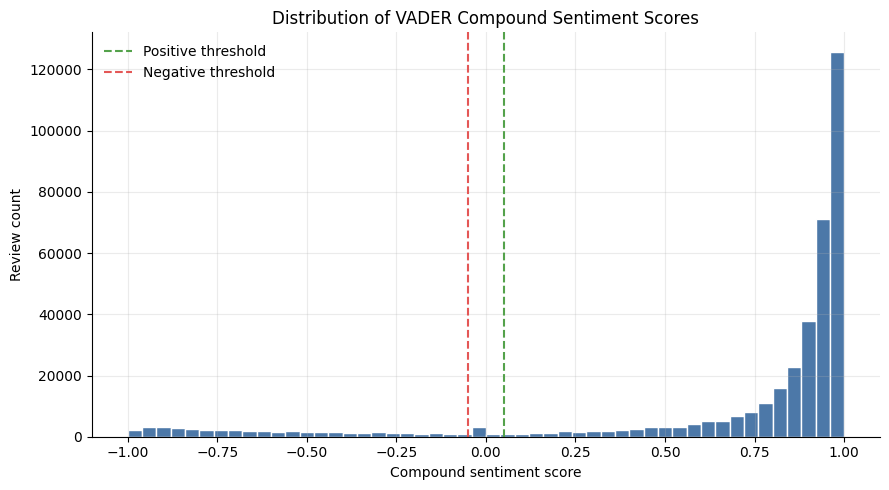

outputs\figures\eda\sentiment_distribution.png


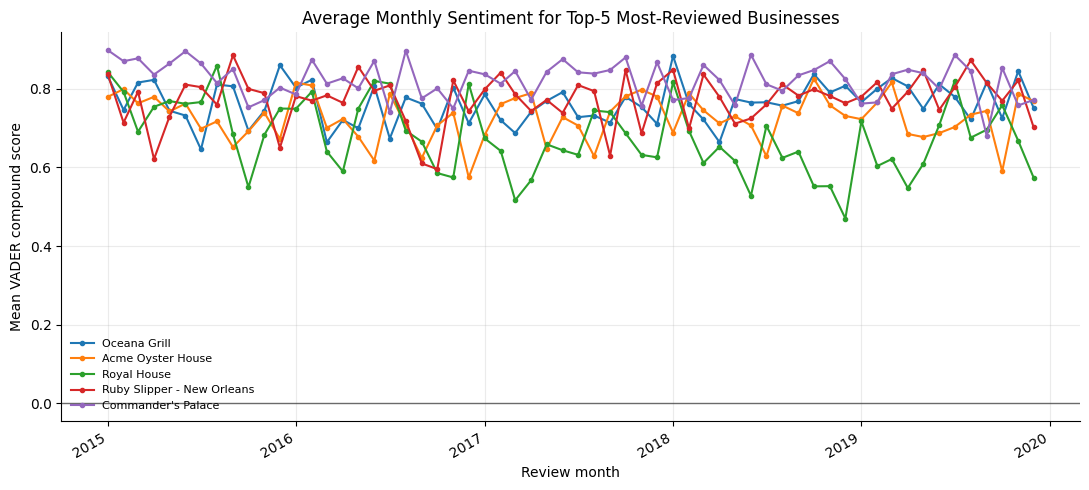

outputs\figures\eda\sentiment_trend_top5.png


(              business_id feature_month  sentiment_compound_mean  \
 0  -1XSzguS6XLN-V6MVZMg2A       2015-01                      0.0   
 1  -1XSzguS6XLN-V6MVZMg2A       2015-02                      0.0   
 2  -1XSzguS6XLN-V6MVZMg2A       2015-03                      0.0   
 3  -1XSzguS6XLN-V6MVZMg2A       2015-04                      0.0   
 4  -1XSzguS6XLN-V6MVZMg2A       2015-05                      0.0   
 
    sentiment_positive_pct  sentiment_negative_pct  
 0                     0.0                     0.0  
 1                     0.0                     0.0  
 2                     0.0                     0.0  
 3                     0.0                     0.0  
 4                     0.0                     0.0  ,
 {'review_count': 385655,
  'mean_compound': 0.6959832290518727,
  'median_compound': 0.9229,
  'positive_review_pct': 87.95088874771493,
  'negative_review_pct': 10.961092167870246,
  'neutral_review_pct': 1.0880190844148268})

In [25]:
# Prepare reviews
reviews_df = reviews[["business_id", "user_id", "stars", "text", "date"]].copy()
reviews_df["text"] = reviews_df["text"].fillna("").astype(str)
reviews_df["year_month"] = reviews_df["date"].dt.to_period("M")
reviews_df = reviews_df[
    (reviews_df["year_month"] >= MODELING_START)
    & (reviews_df["year_month"] <= MODELING_END_TARGET)
].copy()

# Score sentiment
sentiment_analyzer = SentimentIntensityAnalyzer()
reviews_df["compound"] = reviews_df["text"].apply(lambda text: sentiment_analyzer.polarity_scores(text)["compound"])
reviews_df["is_positive_sentiment"] = reviews_df["compound"].gt(VADER_POSITIVE_THRESHOLD)
reviews_df["is_negative_sentiment"] = reviews_df["compound"].lt(VADER_NEGATIVE_THRESHOLD)

# Monthly sentiment
monthly_sentiment = (
    reviews_df
    .groupby(["business_id", "year_month"])
    .agg(
        sentiment_compound_mean=("compound", "mean"),
        sentiment_positive_pct=("is_positive_sentiment", lambda values: values.mean() * 100),
        sentiment_negative_pct=("is_negative_sentiment", lambda values: values.mean() * 100),
    )
    .reset_index()
    .rename(columns={"year_month": "feature_month"})
)

sentiment_feature_columns = [
    "sentiment_compound_mean",
    "sentiment_positive_pct",
    "sentiment_negative_pct",
]

# Add sentiment features
panel = panel.merge(monthly_sentiment, on=["business_id", "feature_month"], how="left")

for column in sentiment_feature_columns:
    panel[column] = panel[column].fillna(0.0)

# Sentiment summary
sentiment_distribution_summary = {
    "review_count": int(len(reviews_df)),
    "mean_compound": float(reviews_df["compound"].mean()),
    "median_compound": float(reviews_df["compound"].median()),
    "positive_review_pct": float(reviews_df["is_positive_sentiment"].mean() * 100),
    "negative_review_pct": float(reviews_df["is_negative_sentiment"].mean() * 100),
    "neutral_review_pct": float((~reviews_df["is_positive_sentiment"] & ~reviews_df["is_negative_sentiment"]).mean() * 100),
}

# Plot sentiment distribution
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(reviews_df["compound"], bins=50, color="#4C78A8", edgecolor="white")
ax.axvline(VADER_POSITIVE_THRESHOLD, color="#54A24B", linestyle="--", linewidth=1.5, label="Positive threshold")
ax.axvline(VADER_NEGATIVE_THRESHOLD, color="#E45756", linestyle="--", linewidth=1.5, label="Negative threshold")
ax.set_title("Distribution of VADER Compound Sentiment Scores")
ax.set_xlabel("Compound sentiment score")
ax.set_ylabel("Review count")
ax.legend(frameon=False)
fig.tight_layout()

# Save distribution figure
sentiment_distribution_path = EDA_FIGURES_DIR / "sentiment_distribution.png"
fig.savefig(sentiment_distribution_path, dpi=160, bbox_inches="tight")
plt.show()
print(sentiment_distribution_path.relative_to(PROJECT_ROOT))

# Top businesses
top5_business_ids = reviews_df["business_id"].value_counts().head(5).index.tolist()
business_name_lookup = businesses.set_index("business_id")["name"].to_dict()


# Plot label
def sentiment_plot_label(business_id):
    label = business_name_lookup.get(business_id) or business_id
    return label if len(label) <= 38 else f"{label[:35]}..."


# Plot sentiment trends
fig, ax = plt.subplots(figsize=(11, 5))

for business_id in top5_business_ids:
    trend = monthly_sentiment[monthly_sentiment["business_id"].eq(business_id)].sort_values("feature_month").copy()
    trend["month_start"] = trend["feature_month"].dt.to_timestamp()
    ax.plot(
        trend["month_start"],
        trend["sentiment_compound_mean"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=sentiment_plot_label(business_id),
    )

ax.axhline(0, color="#333333", linewidth=1, alpha=0.7)
ax.set_title("Average Monthly Sentiment for Top-5 Most-Reviewed Businesses")
ax.set_xlabel("Review month")
ax.set_ylabel("Mean VADER compound score")
ax.legend(frameon=False, fontsize=8)
fig.autofmt_xdate()
fig.tight_layout()

# Save trend figure
sentiment_trend_path = EDA_FIGURES_DIR / "sentiment_trend_top5.png"
fig.savefig(sentiment_trend_path, dpi=160, bbox_inches="tight")
plt.show()
print(sentiment_trend_path.relative_to(PROJECT_ROOT))

panel[["business_id", "feature_month"] + sentiment_feature_columns].head(), sentiment_distribution_summary

VADER sentiment confirms that review text is strongly positive: about 88% of reviews are positive, with a high median compound score of 0.923. For the top-reviewed businesses, monthly sentiment stays mostly stable between 0.6 and 0.9, suggesting consistent customer approval rather than major sentiment swings. Any zero sentiment rows should be read as months with no review signal, not neutral opinions.

## Final Dataset and Validation

Let's apply here the attention-pulse definition, remove pre-first-review rows and save the modeling table.

In [26]:
# Modeling rows
modeling = panel[
    (panel["feature_month"] >= MODELING_START)
    & (panel["feature_month"] <= MODELING_END_FEATURE)
].copy()

# First active month
first_active_feature_month = (
    panel[panel["monthly_review_count"] > 0]
    .groupby("business_id")["feature_month"]
    .min()
    .rename("first_active_feature_month")
)

modeling = modeling.merge(first_active_feature_month, on="business_id", how="left")
pre_first_review_rows = int((modeling["feature_month"] < modeling["first_active_feature_month"]).sum())
modeling = modeling[modeling["feature_month"] >= modeling["first_active_feature_month"]].copy()

# Calendar features
modeling["feature_month_str"] = modeling["feature_month"].astype(str)
modeling["target_month_str"] = modeling["target_month"].astype(str)
modeling["calendar_month"] = modeling["feature_month"].dt.month
modeling["month_sin"] = np.sin(2 * np.pi * modeling["calendar_month"] / 12)
modeling["month_cos"] = np.cos(2 * np.pi * modeling["calendar_month"] / 12)
modeling["feature_month_number"] = (
    (modeling["feature_month"].dt.year - 2015) * 12
    + modeling["feature_month"].dt.month
)

# Attention pulse target
modeling["pulse_baseline_reviews"] = modeling["rolling_6_avg"]
modeling["pulse_relative_lift"] = modeling["target_next_month_reviews"] / np.maximum(modeling["pulse_baseline_reviews"], 1)

modeling["attention_pulse"] = (
    (modeling["target_next_month_reviews"] >= PULSE_MIN_TARGET_REVIEWS)
    & (modeling["target_next_month_reviews"] >= modeling["pulse_baseline_reviews"] + PULSE_ABSOLUTE_LIFT)
    & (modeling["target_next_month_reviews"] >= PULSE_RELATIVE_LIFT * np.maximum(modeling["pulse_baseline_reviews"], 1))
).astype(int)

# Final date columns
modeling["first_active_feature_month_str"] = modeling["first_active_feature_month"].astype(str)
modeling = modeling.drop(columns=["feature_month", "target_month", "first_active_feature_month"])

# Validation checks
assert modeling["target_next_month_reviews"].notna().all()
assert not (modeling["target_month_str"] >= "2020-01").any()
assert (cohort["total_reviews"] >= MIN_TOTAL_REVIEWS).all()
assert (cohort["active_months"] >= MIN_ACTIVE_MONTHS).all()
assert (modeling["feature_month_str"] < modeling["target_month_str"]).all()
assert (modeling["feature_month_str"] >= modeling["first_active_feature_month_str"]).all()
assert all(column in modeling.columns for column in dynamic_social_exposure_features)
assert all(column in modeling.columns for column in nlp_feature_columns)
assert all(column in modeling.columns for column in sentiment_feature_columns)
assert modeling["attention_pulse"].isin([0, 1]).all()

# Save modeling table
modeling.to_csv(FORECASTING_DATASET_PATH, index=False)
modeling.to_parquet(MODELING_TABLE_WITH_SENTIMENT_PATH, index=False)

# Feature summary
summary = {
    "min_total_reviews": MIN_TOTAL_REVIEWS,
    "min_active_months": MIN_ACTIVE_MONTHS,
    "business_count": len(cohort_ids),
    "row_count": len(modeling),
    "feature_month_min": modeling["feature_month_str"].min(),
    "feature_month_max": modeling["feature_month_str"].max(),
    "target_month_min": modeling["target_month_str"].min(),
    "target_month_max": modeling["target_month_str"].max(),
    "excluded_post_modeling_start": EXCLUDED_POST_MODELING_START,
    "excluded_pre_first_review_rows": pre_first_review_rows,
    "cohort_activity_window": {
        "start": str(MODELING_START),
        "end": str(MODELING_END_TARGET),
        "min_total_reviews": MIN_TOTAL_REVIEWS,
        "min_active_months": MIN_ACTIVE_MONTHS,
    },
    "attention_pulse_definition": {
        "min_target_reviews": PULSE_MIN_TARGET_REVIEWS,
        "absolute_lift_vs_rolling_6": PULSE_ABSOLUTE_LIFT,
        "relative_lift_vs_rolling_6_or_one": PULSE_RELATIVE_LIFT,
    },
    "attention_pulse_rate": float(modeling["attention_pulse"].mean()),
    "recent_text_window_months": RECENT_TEXT_WINDOW_MONTHS,
    "nlp_features": nlp_feature_columns,
    "sentiment_features": sentiment_feature_columns,
    "tfidf_feature_count": len(tfidf_feature_columns),
    "tfidf_terms_output": str(TFIDF_TERMS_OUTPUT_PATH.relative_to(PROJECT_ROOT)),
    "dynamic_active_review_threshold": DYNAMIC_ACTIVE_REVIEW_THRESHOLD,
    "high_social_signal_quantile": HIGH_SOCIAL_SIGNAL_QUANTILE,
    "static_social_features": static_social_features,
    "dynamic_social_exposure_features": dynamic_social_exposure_features,
    "output": str(FORECASTING_DATASET_PATH.relative_to(PROJECT_ROOT)),
    "sentiment_output": str(MODELING_TABLE_WITH_SENTIMENT_PATH.relative_to(PROJECT_ROOT)),
}

# Save summary
with FEATURE_SUMMARY_PATH.open("w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2)
    file.write("\n")

summary

{'min_total_reviews': 100,
 'min_active_months': 36,
 'business_count': 715,
 'row_count': 40822,
 'feature_month_min': '2015-01',
 'feature_month_max': '2019-11',
 'target_month_min': '2015-02',
 'target_month_max': '2019-12',
 'excluded_post_modeling_start': '2020-01',
 'excluded_pre_first_review_rows': 1363,
 'cohort_activity_window': {'start': '2015-01',
  'end': '2019-12',
  'min_total_reviews': 100,
  'min_active_months': 36},
 'attention_pulse_definition': {'min_target_reviews': 3,
  'absolute_lift_vs_rolling_6': 2,
  'relative_lift_vs_rolling_6_or_one': 1.5},
 'attention_pulse_rate': 0.1541325755719955,
 'recent_text_window_months': 3,
 'nlp_features': ['recent_text_review_count',
  'avg_recent_review_char_count',
  'avg_recent_review_word_count',
  'share_recent_positive_language',
  'share_recent_negative_language',
  'avg_recent_positive_word_hits',
  'avg_recent_negative_word_hits',
  'recent_text_avg_stars',
  'tfidf_recent_amazing',
  'tfidf_recent_bar',
  'tfidf_recent_b

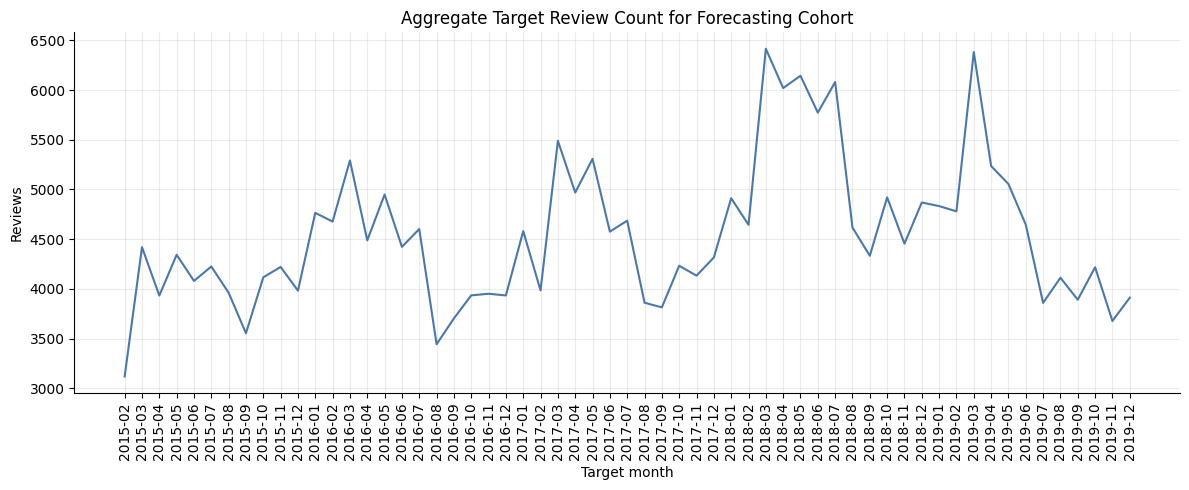

outputs\figures\feature_engineering\cohort_monthly_target_reviews.png


In [27]:
# Monthly target volume
monthly_target = modeling.groupby("target_month_str")["target_next_month_reviews"].sum()

# Plot target reviews
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_target.index, monthly_target.values, color="#4C78A8")
ax.set_title("Aggregate Target Review Count for Forecasting Cohort")
ax.set_xlabel("Target month")
ax.set_ylabel("Reviews")
ax.tick_params(axis="x", rotation=90)
fig.tight_layout()

# Save figure
path = FIGURES_DIR / "cohort_monthly_target_reviews.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)

print(path.relative_to(PROJECT_ROOT))

For the forecasting cohort, target review volume is volatile rather than smoothly trending. Peaks in 2018 and early 2019 show bursts of high activity, while later 2019 declines toward lower levels. This suggests the forecasting task must handle short-term fluctuations, not just long-run growth.

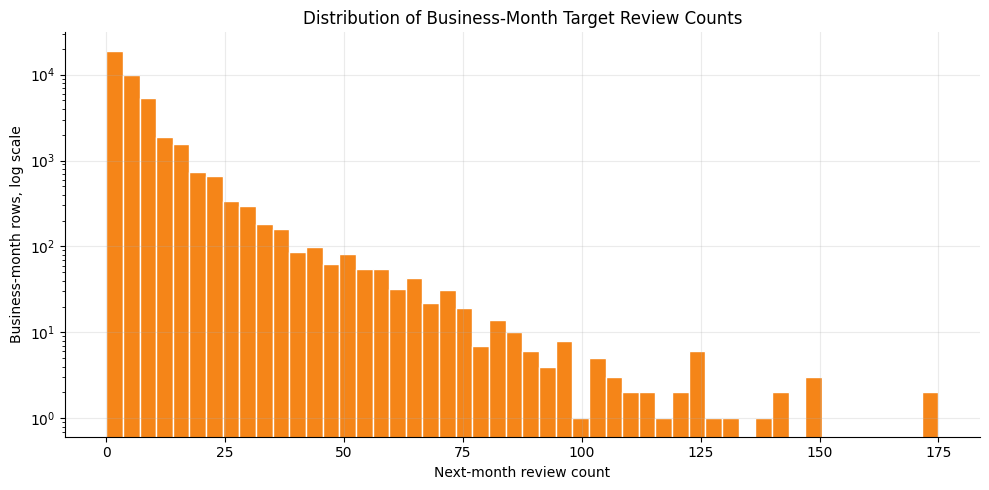

outputs\figures\feature_engineering\target_review_count_distribution.png


In [28]:
# Save the target distribution figure with log-scaled counts.
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(modeling["target_next_month_reviews"], bins=50, color="#F58518", edgecolor="white")
ax.set_yscale("log")
ax.set_title("Distribution of Business-Month Target Review Counts")
ax.set_xlabel("Next-month review count")
ax.set_ylabel("Business-month rows, log scale")
fig.tight_layout()
path = FIGURES_DIR / "target_review_count_distribution.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)
print(path.relative_to(PROJECT_ROOT))

The target variable is highly skewed at the business-month level: most businesses receive very few next-month reviews, while only a small number reach high counts. This makes forecasting difficult because the model must predict many near-zero cases while still capturing rare high-volume spikes.

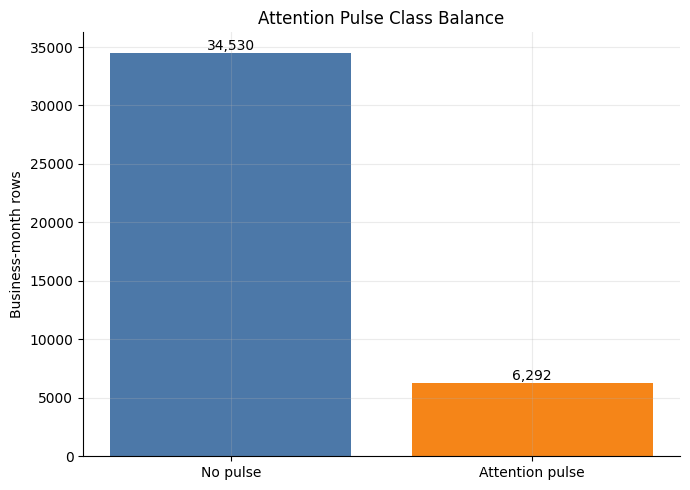

outputs\figures\feature_engineering\attention_pulse_class_balance.png


In [29]:
# Save the attention-pulse class-balance figure.
pulse_counts = modeling["attention_pulse"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["No pulse", "Attention pulse"], [pulse_counts.get(0, 0), pulse_counts.get(1, 0)], color=["#4C78A8", "#F58518"])
ax.set_title("Attention Pulse Class Balance")
ax.set_ylabel("Business-month rows")
for index, value in enumerate([pulse_counts.get(0, 0), pulse_counts.get(1, 0)]):
    ax.text(index, value, f"{value:,}", ha="center", va="bottom")
fig.tight_layout()
path = FIGURES_DIR / "attention_pulse_class_balance.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)
print(path.relative_to(PROJECT_ROOT))

Attention pulses are relatively rare: only 6,292 business-months are labeled as pulses compared with 34,530 non-pulse cases. This class imbalance means pulse prediction is harder than standard review-count forecasting and requires care in evaluation, since a model could perform well overall while missing many pulse events.

## Feature-Engineering Limitations

- The attention-pulse rule is intentionally interpretable, but it is still a design choice rather than an observed ground truth label.
- Community labels come from the active reviewer graph; reviews by unlabeled users are assigned `community_id = -1` and excluded from community-month aggregation.
- Community-month series smooth out business-level noise, but they do not identify which specific businesses will receive attention.
- NLP features are lightweight lexicon, VADER sentiment, text-length, and capped TF-IDF signals; they improve interpretability but do not replace deeper semantic modeling.
- TF-IDF values use only recent reviews for each business-month, but the vocabulary itself is selected globally as a simple feature set mainly for interpretability.
- VADER is rule-based sentiment analysis, so sarcasm, local slang, and mixed food/service experiences can still be misread.

## Feature-Engineering Takeaways

- The cohort is selected using activity inside the actual **2015-2019 pre-COVID modeling window**, not the full historical Yelp period.
- Rows before each business's first observed modeling-window review are excluded, avoiding artificial all-zero pre-visibility periods.
- Attention pulses flag unusual next-month review increases relative to each business's rolling 6-month baseline.
- Community-month series show that large reviewer communities have aggregate rhythms within the pre-COVID modeling scope.
- NLP features use only reviews from the feature month and previous two months.
- VADER sentiment features summarize same-month review tone as mean compound score plus positive and negative review percentages.
- SNA features describe recent reviewers as of the feature month.
- The saved figures document aggregate review activity, community trends, target skew, attention-pulse class balance, and sentiment patterns.
